Análise dos Dados

In [51]:
import os, sys, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd

import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
try:
    pio.renderers.default = "notebook_connected"
except Exception:
    pio.renderers.default = "notebook"

def find_processed_dir(start: Path) -> Path | None:
    """
    Sobe a árvore de diretórios a partir de `start` procurando por data/processed_data.
    Retorna o caminho se existir; caso contrário, None.
    """
    cur = start.resolve()
    for _ in range(8):  # sobe até 8 níveis
        candidate = cur / "data" / "processed_data"
        if candidate.exists():
            return candidate
        cur = cur.parent
    return None

# Aqui é o ponto de partida, diretório do notebook (separado do CWD do kernel)
try:
    # No JupyterLab/VSCode, isto pega a pasta do arquivo aberto
    NOTEBOOK_DIR = Path(__file__).parent.resolve()  # type: ignore[name-defined]
except Exception:
    # Fallback vai usar o diretório atual do processo 
    NOTEBOOK_DIR = Path.cwd().resolve()

PROC_DIR = find_processed_dir(NOTEBOOK_DIR)

# Se não encontrou subindo a árvore, tenta procurar pelo arquivo no projeto
csv_default = None
if PROC_DIR is not None:
    csv_default = PROC_DIR / "base_acidente.csv"

if csv_default is None or not csv_default.exists():
    # varre por qualquer base_acidente.csv no projeto aberto
    matches = list(Path(NOTEBOOK_DIR.anchor or ".").glob("**/base_acidente.csv"))
    if matches:
        csv_default = matches[0]
    else:
        raise FileNotFoundError(
            "Não encontrei 'base_acidente.csv'. Gere o consolidado na Parte 1 "
            "ou coloque o arquivo em 'data/processed_data/'."
        )

print(f"Arquivo encontrado: {csv_default}")

base = pd.read_csv(csv_default, encoding="latin-1", sep=",", low_memory=False)

# Normalizações úteis (mesmo que antes) 
base.columns = [c.strip() for c in base.columns]
if "data_inversa" in base.columns and not np.issubdtype(base["data_inversa"], np.datetime64):
    base["data_inversa"] = pd.to_datetime(base["data_inversa"], errors="coerce")

if "year" not in base.columns and "data_inversa" in base.columns:
    base["year"] = base["data_inversa"].dt.year
    base["month"] = base["data_inversa"].dt.month
    base["day"] = base["data_inversa"].dt.day
    base["weekday_num"] = base["data_inversa"].dt.dayofweek

if "horario" in base.columns and not np.issubdtype(base["horario"], np.datetime64):
    base["horario"] = pd.to_datetime(base["horario"], format="%H:%M:%S", errors="coerce")
if "HORA" not in base.columns and "horario" in base.columns:
    base["HORA"] = base["horario"].dt.hour.fillna(-1).astype(int)

if "uf" in base.columns:
    base["uf"] = base["uf"].astype(str).str.upper().str.strip()
if "municipio" in base.columns:
    base["municipio"] = base["municipio"].astype(str).str.upper().str.strip()

if "TOTAL_FERIDOS" not in base.columns:
    base["TOTAL_FERIDOS"] = base.get("feridos_leves", 0).fillna(0) + base.get("feridos_graves", 0).fillna(0)

for c in ["mortos", "pessoas", "veiculos", "TOTAL_FERIDOS"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce").fillna(0)

print("Linhas:", f"{len(base):,}", "| Colunas:", len(base.columns))

Arquivo encontrado: C:\Users\Willgnner\Documents\Data_Schience-_UFG_Case\src\data\processed_data\base_acidente.csv
Linhas: 560,138 | Colunas: 39


In [52]:
import unicodedata

# garante colunas esperadas
assert "uf" in base.columns and "municipio" in base.columns, "Faltam colunas 'uf' e/ou 'municipio'!"

df_go = base[base["uf"] == "GO"].copy()

print("Top 30 municípios (GO) por nº de ocorrências:")
print(df_go["municipio"].value_counts().head(30))

Top 30 municípios (GO) por nº de ocorrências:
municipio
ANAPOLIS                 2394
GOIANIA                  2274
VALPARAISO DE GOIAS      1771
LUZIANIA                 1656
APARECIDA DE GOIANIA     1553
CRISTALINA               1096
RIO VERDE                1068
AGUAS LINDAS DE GOIAS     915
JATAI                     820
CATALAO                   753
FORMOSA                   713
ALEXANIA                  691
ABADIANIA                 567
MORRINHOS                 526
ITUMBIARA                 461
HIDROLANDIA               448
GOIANAPOLIS               422
URUACU                    391
COCALZINHO DE GOIAS       383
PORANGATU                 363
CAMPO ALEGRE DE GOIAS     352
PROFESSOR JAMIL           331
JARAGUA                   299
GUAPO                     283
ABADIA DE GOIAS           267
MINEIROS                  265
TEREZOPOLIS DE GOIAS      254
PADRE BERNARDO            229
ACREUNA                   222
ALVORADA DO NORTE         211
Name: count, dtype: int64


In [53]:
import re
import numpy as np
import pandas as pd

def normalize_txt(s: str) -> str:
    """Upper, sem acento, sem espaços duplicados, strip."""
    if pd.isna(s):
        return s
    s = str(s).strip()
    # remove acentos
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    # upper e compacta espaços
    s = re.sub(r"\s+", " ", s.upper())
    return s

# cria colunas normalizadas para UF e município
base["UF_NORM"] = base["uf"].map(normalize_txt)
base["MUNICIPIO_NORM"] = base["municipio"].map(normalize_txt)

# Goiás
df_go = base[base["UF_NORM"] == "GO"].copy()

# Lista normalizada da RMG (municípios oficiais da RMG)
rmg_lista_norm = {
    "GOIANIA",
    "APARECIDA DE GOIANIA",
    "SENADOR CANEDO",
    "TRINDADE",
    "GOIANAPOLIS",
    "TEREZOPOLIS DE GOIAS",
    "HIDROLANDIA",
    "ABADIA DE GOIAS",
    "GUAPO",
    "NEROPOLIS",
    "INHUMAS",
    "BELA VISTA DE GOIAS",
    "ARAGOIANIA"
}

df_rmg = df_go[df_go["MUNICIPIO_NORM"].isin(rmg_lista_norm)].copy()

print("Subconjuntos criados (normalização aplicada).")
print(f"GO: {len(df_go):,} registros  |  RMG (Goiânia + entorno): {len(df_rmg):,} registros")
print("\nTop 15 municípios na RMG filtrada:")
print(df_rmg["municipio"].value_counts().head(15))

# Fallback geográfico, retângulo aproximado da RMG
tem_geo = {"latitude","longitude"}.issubset(df_go.columns)
if tem_geo:
    # garante float
    for c in ["latitude","longitude"]:
        df_go[c] = pd.to_numeric(df_go[c], errors="coerce")

    # bounding box aproximado 
    lat_min, lat_max = -17.2, -16.2
    lon_min, lon_max = -50.2, -48.8

    df_rmg_geo = df_go[
        (df_go["latitude"].between(lat_min, lat_max)) &
        (df_go["longitude"].between(lon_min, lon_max))
    ].copy()

    print(f"\nFiltro geográfico (bbox RMG) capturou: {len(df_rmg_geo):,} registros.")
    print("Top 10 municípios nesse bbox:")
    print(df_rmg_geo["municipio"].value_counts().head(10))

Subconjuntos criados (normalização aplicada).
GO: 27,165 registros  |  RMG (Goiânia + entorno): 5,505 registros

Top 15 municípios na RMG filtrada:
municipio
GOIANIA                 2274
APARECIDA DE GOIANIA    1553
HIDROLANDIA              448
GOIANAPOLIS              422
GUAPO                    283
ABADIA DE GOIAS          267
TEREZOPOLIS DE GOIAS     254
TRINDADE                   4
Name: count, dtype: int64

Filtro geográfico (bbox RMG) capturou: 8,258 registros.
Top 10 municípios nesse bbox:
municipio
GOIANIA                 2272
ANAPOLIS                2265
APARECIDA DE GOIANIA    1553
HIDROLANDIA              448
GOIANAPOLIS              422
GUAPO                    283
ABADIA DE GOIAS          267
TEREZOPOLIS DE GOIAS     254
INDIARA                  185
CEZARINA                 151
Name: count, dtype: int64


In [54]:
# Tendências Anuais (GO x RMG) — replot

from plotly.subplots import make_subplots
import plotly.graph_objects as go

def KPIs(df, nome="DF"):
    total = len(df)
    mortos = int(df["mortos"].sum()) if "mortos" in df.columns else 0
    feridos = int(df.get("TOTAL_FERIDOS", (df.get("feridos_leves",0)+df.get("feridos_graves",0))).sum())
    taxa_mortalidade = (df["mortos"].sum() / total * 100) if total > 0 else 0
    print(f"{nome}")
    print(f"Registros: {total:,}")
    print(f"Mortos: {mortos:,}")
    print(f"Feridos (leves+graves): {feridos:,}")
    print(f"Taxa bruta de mortalidade (por ocorrência): {taxa_mortalidade:.2f}%")

KPIs(df_go, "Goiás (GO)")
KPIs(df_rmg, "RMG (Goiânia + entorno)")

# Garante coluna 'year'
if "year" not in df_go.columns and "data_inversa" in df_go.columns:
    df_go["year"] = pd.to_datetime(df_go["data_inversa"], errors="coerce").dt.year
if "year" not in df_rmg.columns and "data_inversa" in df_rmg.columns:
    df_rmg["year"] = pd.to_datetime(df_rmg["data_inversa"], errors="coerce").dt.year

def tendencia_anual_plot(df_go, df_rmg):
    ag_go = df_go.groupby("year", dropna=True).agg(registros=("year","size"), mortos=("mortos","sum")).reset_index()
    ag_rmg = df_rmg.groupby("year", dropna=True).agg(registros=("year","size"), mortos=("mortos","sum")).reset_index()

    # garante anos contínuos para não “quebrar” a linha
    anos = sorted(set(ag_go["year"]).union(set(ag_rmg["year"])))
    ag_go = ag_go.set_index("year").reindex(anos, fill_value=0).reset_index()
    ag_rmg = ag_rmg.set_index("year").reindex(anos, fill_value=0).reset_index()

    fig = make_subplots(rows=1, cols=2, subplot_titles=("Ocorrências por ano", "Mortes por ano"))

    fig.add_trace(go.Scatter(x=ag_go["year"], y=ag_go["registros"], name="GO — ocorrências",
                             mode="lines+markers"), row=1, col=1)
    fig.add_trace(go.Scatter(x=ag_rmg["year"], y=ag_rmg["registros"], name="RMG — ocorrências",
                             mode="lines+markers"), row=1, col=1)

    fig.add_trace(go.Scatter(x=ag_go["year"], y=ag_go["mortos"], name="GO — mortos",
                             mode="lines+markers"), row=1, col=2)
    fig.add_trace(go.Scatter(x=ag_rmg["year"], y=ag_rmg["mortos"], name="RMG — mortos",
                             mode="lines+markers"), row=1, col=2)

    fig.update_layout(title="Tendência anual — GO x RMG",
                      height=450, hovermode="x unified", template="plotly_white")
    fig.update_xaxes(title="Ano", row=1, col=1); fig.update_yaxes(title="Ocorrências", row=1, col=1)
    fig.update_xaxes(title="Ano", row=1, col=2); fig.update_yaxes(title="Mortos", row=1, col=2)
    fig.show()

tendencia_anual_plot(df_go, df_rmg)

Goiás (GO)
Registros: 27,165
Mortos: 2,354
Feridos (leves+graves): 30,241
Taxa bruta de mortalidade (por ocorrência): 8.67%
RMG (Goiânia + entorno)
Registros: 5,505
Mortos: 207
Feridos (leves+graves): 5,521
Taxa bruta de mortalidade (por ocorrência): 3.76%


In [55]:
# Sazonalidade Mensal e Padrão Semanal/Horário (GO)

# 1) Mensal
mensal = (df_go.groupby("month")
          .agg(ocorrencias=("month", "size"), mortos=("mortos", "sum"))
          .reset_index().sort_values("month"))

fig = make_subplots(rows=1, cols=2, subplot_titles=("Ocorrências por mês (GO)", "Mortes por mês (GO)"))
fig.add_trace(go.Bar(x=mensal["month"], y=mensal["ocorrencias"], name="Ocorrências"), row=1, col=1)
fig.add_trace(go.Bar(x=mensal["month"], y=mensal["mortos"], name="Mortes"), row=1, col=2)
fig.update_layout(height=400, template="plotly_white")
fig.update_xaxes(dtick=1, title="Mês", row=1, col=1); fig.update_yaxes(title="Qtd", row=1, col=1)
fig.update_xaxes(dtick=1, title="Mês", row=1, col=2); fig.update_yaxes(title="Qtd", row=1, col=2)
fig.show()

# 2) Semana/Hora
sem_hora = (
    df_go
    .assign(
        weekday_num=lambda x: x["data_inversa"].dt.weekday if "data_inversa" in x.columns else x["weekday_num"],
        weekday=lambda x: x["data_inversa"].dt.day_name(locale="pt_BR") if "data_inversa" in x.columns else x["weekday"]
    )
    .assign(HORA=lambda x: x["HORA"].clip(lower=0, upper=23))
    .groupby(["weekday_num", "HORA"])
    .size()
    .reset_index(name="ocorrencias")
)

# Ajuste nome do dia em pt-BR 
dias = {0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sáb", 6: "Dom"}
sem_hora["weekday"] = sem_hora["weekday_num"].map(dias)

# Heatmap
fig = px.imshow(
    sem_hora.pivot(index="weekday", columns="HORA", values="ocorrencias")
            .loc[["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"]],
    aspect="auto",
    color_continuous_scale="Reds",
    labels=dict(x="Hora", y="Dia", color="Ocorrências"),
    title="Heatmap — Ocorrências por dia x hora (GO)"
)
fig.update_layout(height=450, template="plotly_white")
fig.show()

In [56]:
# Tipos e Causas de Acidentes (GO x RMG) + Severidade

def top_barras(df, coluna, titulo, top=12):
    aux = (df.groupby(coluna)
           .agg(ocorrencias=(coluna, "size"),
                mortos=("mortos", "sum"),
                feridos=("TOTAL_FERIDOS", "sum"))
           .reset_index()
           .sort_values("ocorrencias", ascending=False)
           .head(top))
    aux["mortalidade_por_ocorr"] = aux["mortos"] / aux["ocorrencias"]
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{titulo} — ocorrências", f"{titulo} — mortalidade média"))
    fig.add_trace(go.Bar(x=aux[coluna], y=aux["ocorrencias"], name="Ocorrências"), row=1, col=1)
    fig.add_trace(go.Bar(x=aux[coluna], y=aux["mortalidade_por_ocorr"], name="Mortos/ocorr."), row=1, col=2)
    fig.update_layout(height=500, template="plotly_white")
    fig.update_xaxes(tickangle=35)
    fig.show()
    return aux

print("TIPOS (GO)"); tipos_go = top_barras(df_go, "tipo_acidente", "Tipos (GO)")
print("TIPOS (RMG)"); tipos_rmg = top_barras(df_rmg, "tipo_acidente", "Tipos (RMG)")
print("CAUSAS (GO)"); causas_go = top_barras(df_go, "causa_acidente", "Causas (GO)")
print("CAUSAS (RMG)"); causas_rmg = top_barras(df_rmg, "causa_acidente", "Causas (RMG)")

TIPOS (GO)


TIPOS (RMG)


CAUSAS (GO)


CAUSAS (RMG)


In [57]:
# Hotspots por BR e por Trecho de 10 km (GO)

# BRs mais críticas em GO
by_br = (df_go.groupby("br")
         .agg(ocorrencias=("br","size"), mortos=("mortos","sum"), feridos=("TOTAL_FERIDOS","sum"))
         .reset_index())

# Índice simples de periculosidade (combina frequência + severidade)
by_br["indice"] = (0.4*by_br["ocorrencias"]/by_br["ocorrencias"].max() + 
                   0.6*by_br["mortos"]/by_br["mortos"].replace(0, np.nan).max()).fillna(0) * 10

top_br = by_br.sort_values("indice", ascending=False).head(15)
fig = px.bar(top_br, x="br", y="indice", title="TOP BRs por índice de periculosidade (GO)",
             labels={"br":"BR","indice":"Índice (0-10)"}, text=top_br["indice"].round(2))
fig.update_traces(textposition="outside")
fig.update_layout(template="plotly_white", height=420)
fig.show()

# Trechos de 10km
df_go["km"] = pd.to_numeric(df_go.get("km", np.nan), errors="coerce")
df_go["km_trecho"] = (df_go["km"]//10)*10

trechos = (df_go.groupby(["br","km_trecho"])
           .agg(ocorrencias=("br","size"),
                mortos=("mortos","sum"),
                feridos=("TOTAL_FERIDOS","sum"),
                municipios=("municipio", lambda x: ", ".join(sorted(set(map(str, x)))[:3])))
           .reset_index())

trechos["indice"] = (0.3*trechos["ocorrencias"]/trechos["ocorrencias"].max() +
                     0.7*trechos["mortos"]/trechos["mortos"].replace(0, np.nan).max()).fillna(0)*10

top_trechos = trechos.sort_values("indice", ascending=False).head(20)
top_trechos["trecho_label"] = top_trechos.apply(
    lambda r: f"BR-{int(r['br'])} km {int(r['km_trecho'])}-{int(r['km_trecho']+10)}", axis=1
)

fig = px.bar(top_trechos.sort_values("indice"),
             y="trecho_label", x="indice", orientation="h",
             title="Top 20 Trechos (10 km) — Índice de Periculosidade (GO)",
             labels={"indice":"Índice (0-10)","trecho_label":"Trecho"},
             text=top_trechos["indice"].round(2))
fig.update_traces(textposition="outside")
fig.update_layout(template="plotly_white", height=650)
fig.show()

top_trechos.head(10)

,br,km_trecho,ocorrencias,mortos,feridos,municipios,indice,trecho_label
30,40,0.0000,2088,44,2052,"CIDADE OCIDENTAL, LUZIANIA, VALPARAISO DE GOIAS",9.0392,BR-40 km 0-10
31,40,10.0000,811,51,847,"ALEXANIA, CIDADE OCIDENTAL, LUZIANIA",8.1652,BR-40 km 10-20
235,153,500.0000,1368,41,1403,"APARECIDA DE GOIANIA, GOIANIA, HIDROLANDIA",7.5930,BR-153 km 500-510
32,40,20.0000,313,44,367,"ALEXANIA, CRISTALINA, LUZIANIA",6.4889,BR-40 km 20-30
234,153,490.0000,864,38,793,GOIANIA,6.4571,BR-153 km 490-500
117,70,0.0000,769,29,818,"AGUAS LINDAS DE GOIAS, LUZIANIA",5.0853,BR-70 km 0-10
236,153,510.0000,607,25,607,"APARECIDA DE GOIANIA, GOIANIA, HIDROLANDIA",4.3035,BR-153 km 510-520
2,20,10.0000,107,27,118,FORMOSA,3.8596,BR-20 km 10-20
78,60,90.0000,775,20,825,"ANAPOLIS, GOIANIA",3.8586,BR-60 km 90-100
229,153,430.0000,383,23,389,ANAPOLIS,3.7072,BR-153 km 430-440


Modelagem

In [58]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.inspection import permutation_importance

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.options.display.max_columns = None
pd.options.display.float_format = lambda x: f"{x:,.4f}"

Carregar base consolidada e focar Goiás

In [59]:
# Caminho 
current_dir = os.path.dirname(os.path.abspath('__file__'))
csv_default = os.path.join(current_dir, '..', 'data', 'processed_data', r'C:\Users\Willgnner\Documents\Data_Schience-_UFG_Case\src\data\processed_data\base_acidente.csv')

if not os.path.exists(csv_default):
    raise FileNotFoundError(f"Não encontrei {csv_default}. Gere a base na Parte 1 ou ajuste o caminho.")

base = pd.read_csv(csv_default, encoding='latin-1', sep=',', low_memory=False)

# Normalizações úteis
if "data_inversa" in base.columns and not np.issubdtype(base["data_inversa"], np.datetime64):
    base["data_inversa"] = pd.to_datetime(base["data_inversa"], errors="coerce")
if "horario" in base.columns and not np.issubdtype(base["horario"], np.datetime64):
    base["horario"] = pd.to_datetime(base["horario"], format="%H:%M:%S", errors="coerce")

for c in ["latitude", "longitude", "km"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

# Boas práticas, padronizar UF e município
if "uf" in base.columns:
    base["uf"] = base["uf"].astype(str).str.upper().str.strip()
if "municipio" in base.columns:
    base["municipio"] = (base["municipio"].astype(str)
                         .str.normalize("NFKD")
                         .str.encode("ascii", "ignore").str.decode("utf-8")
                         .str.upper().str.strip())

# Cria TOTAL_FERIDOS caso não exista
if "TOTAL_FERIDOS" not in base.columns:
    base["TOTAL_FERIDOS"] = base.get("feridos_leves", 0).fillna(0) + base.get("feridos_graves", 0).fillna(0)

# Foco no estado de GO
df_go = base[base["uf"] == "GO"].copy()

print(f"Base carregada. Registros totais: {len(base):,} | Goiás: {len(df_go):,}")
df_go.head(3)

Base carregada. Registros totais: 560,138 | Goiás: 27,165


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,year,month,day,weekday,HORA,PERIODO_DIA,TOTAL_FERIDOS,TAXA_MORTALIDADE
4,109.0000,2017-01-01,domingo,NaT,GO,20,220.5000,POSSE,Defeito na Via,ColisÃ£o com objeto estÃ¡tico,NaN,Pleno dia,Decrescente,CÃU CLARO,Simples,Declive,NÃ£o,4,0,2,1,0,1,3,2,-14.1422,-46.3226,SPRF-DF,DEL02-DF,UOP03-DEL02-DF,2017,2017,1,1,6,9,MANHÃ,3,0.0000
59,534.0000,2017-01-02,segunda-feira,NaT,GO,153,696.2000,ITUMBIARA,Defeito MecÃ¢nico no VeÃ­culo,IncÃªndio,Sem VÃ­timas,Pleno dia,Crescente,CÃU CLARO,Simples,Viaduto,Sim,2,0,0,0,1,1,0,2,-18.3590,-49.2170,SPRF-GO,DEL03-GO,UOP02-DEL03-GO,2017,2017,1,2,0,11,MANHÃ,0,0.0000
67,562.0000,2017-01-02,segunda-feira,NaT,GO,153,589.8000,PIRACANJUBA,Falta de AtenÃ§Ã£o Ã ConduÃ§Ã£o,Capotamento,Com VÃ­timas Feridas,Pleno dia,Decrescente,CHUVA,Dupla,Declive,NÃ£o,2,0,0,1,0,1,1,2,-17.4688,-49.2176,SPRF-GO,DEL03-GO,UOP01-DEL03-GO,2017,2017,1,2,0,18,NOITE,1,0.0000


Criar alvo (fatal), features e split treino/teste

In [60]:
# Alvo: 1 se houve pelo menos um morto na ocorrência
df_go["fatal"] = (df_go["mortos"].fillna(0) > 0).astype(int)

# Features
num_features = [
    "veiculos", "pessoas", "TOTAL_FERIDOS", "km"
]
cat_features = [
    "tipo_acidente", "causa_acidente", "tipo_pista",
    "tracado_via", "uso_solo", "dia_semana", "PERIODO_DIA", "municipio", "br"
]

num_features = [c for c in num_features if c in df_go.columns]
cat_features = [c for c in cat_features if c in df_go.columns]

features = num_features + cat_features
target = "fatal"

df_model = df_go.dropna(subset=[target]).copy()

X = df_model[features]
y = df_model[target].astype(int)

# Split estratificado 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Conjunto para modelagem pronto.")
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,} | Positivos no teste: {y_test.mean()*100:.2f}%")

Conjunto para modelagem pronto.
Treino: 20,373 | Teste: 6,792 | Positivos no teste: 7.14%


Pré-processamento (num + cat) com ColumnTransformer

In [61]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  
])

ct = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ],
    remainder="drop",
    sparse_threshold=0.0   # força saída densa mesmo se algo for esparso
)

feature_names_original = list(num_features) + list(cat_features)

Funções de avaliação padronizadas (gráficos e métricas)

In [62]:
def print_metrics(y_true, y_proba, y_pred):
    roc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)
    print(f"ROC-AUC: {roc:.3f} | PR-AUC (AP): {pr:.3f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

def plot_curves(y_true, y_proba, title=""):
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Curva ROC", "Precisão x Revocação"))
    # ROC
    roc_disp = RocCurveDisplay.from_predictions(y_true, y_proba)
    # PR
    pr_disp  = PrecisionRecallDisplay.from_predictions(y_true, y_proba)

    # Converte para plotly
    fig.add_trace(go.Scatter(x=roc_disp.fpr, y=roc_disp.tpr, mode="lines", name="ROC"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pr_disp.recall, y=pr_disp.precision, mode="lines", name="PR"), row=1, col=2)

    fig.update_xaxes(title="FPR", row=1, col=1)
    fig.update_yaxes(title="TPR", row=1, col=1)
    fig.update_xaxes(title="Recall", row=1, col=2)
    fig.update_yaxes(title="Precision", row=1, col=2)
    fig.update_layout(title=title, template="plotly_white", height=420, showlegend=False)
    fig.show()

def find_best_threshold(y_true, y_proba, mode="youden"):
    """
    Otimiza limiar:
    - 'youden' maximiza sensibilidade + especificidade - 1
    - 'f2' maximiza F2-score (recall mais importante)
    """
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_val = 0.5, -np.inf

    from sklearn.metrics import fbeta_score, recall_score, confusion_matrix

    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        if mode == "youden":
            tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
            sens = tp / (tp + fn + 1e-9)
            esp  = tn / (tn + fp + 1e-9)
            val = sens + esp - 1
        else:  # F2
            val = fbeta_score(y_true, pred, beta=2)
        if val > best_val:
            best_val, best_t = val, t
    return best_t, best_val

Baseline: Regressão Logística

logistic Regression (baseline)
ROC-AUC: 0.864 | PR-AUC (AP): 0.370

Classification report:
              precision    recall  f1-score   support

           0      0.978     0.805     0.883      6307
           1      0.232     0.763     0.355       485

    accuracy                          0.802      6792
   macro avg      0.605     0.784     0.619      6792
weighted avg      0.925     0.802     0.846      6792

Confusion matrix:
[[5080 1227]
 [ 115  370]]


Melhor limiar (F2): 0.51 | F2: 0.528

→ Com limiar otimizado (F2):
ROC-AUC: 0.864 | PR-AUC (AP): 0.370

Classification report:
              precision    recall  f1-score   support

           0      0.978     0.813     0.888      6307
           1      0.238     0.759     0.363       485

    accuracy                          0.809      6792
   macro avg      0.608     0.786     0.625      6792
weighted avg      0.925     0.809     0.850      6792

Confusion matrix:
[[5130 1177]
 [ 117  368]]


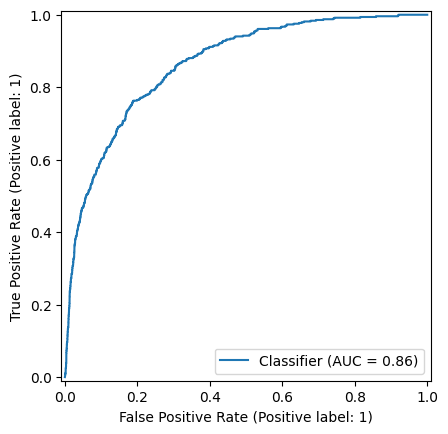

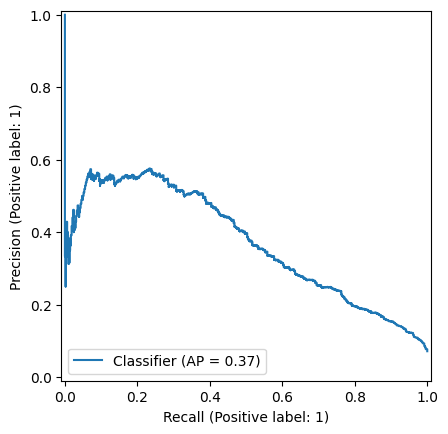

In [63]:
log_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # lida com desbalanceamento
    n_jobs= -1 if hasattr(LogisticRegression(), "n_jobs") else None
)

pipe_log = Pipeline(steps=[("prep", ct), ("clf", log_clf)])
pipe_log.fit(X_train, y_train)

proba_log = pipe_log.predict_proba(X_test)[:, 1]

# limiar default 0.5
pred_log  = (proba_log >= 0.5).astype(int)

print("logistic Regression (baseline)")
print_metrics(y_test, proba_log, pred_log)
plot_curves(y_test, proba_log, title="Baseline — Logistic Regression")

# otimiza limiar (ex.: F2 para priorizar recall de fatais)
best_t, score = find_best_threshold(y_test, proba_log, mode="f2")
print(f"Melhor limiar (F2): {best_t:.2f} | F2: {score:.3f}")
pred_log_opt = (proba_log >= best_t).astype(int)
print("\n→ Com limiar otimizado (F2):")
print_metrics(y_test, proba_log, pred_log_opt)

Modelo 2: RandomForest (robusto) + Permutation Importance

RandomForest
ROC-AUC: 0.886 | PR-AUC (AP): 0.514

Classification report:
              precision    recall  f1-score   support

           0      0.960     0.964     0.962      6307
           1      0.507     0.474     0.490       485

    accuracy                          0.929      6792
   macro avg      0.733     0.719     0.726      6792
weighted avg      0.927     0.929     0.928      6792

Confusion matrix:
[[6083  224]
 [ 255  230]]



→ Limiar Youden: 0.28
ROC-AUC: 0.886 | PR-AUC (AP): 0.514

Classification report:
              precision    recall  f1-score   support

           0      0.985     0.770     0.864      6307
           1      0.220     0.843     0.349       485

    accuracy                          0.775      6792
   macro avg      0.602     0.807     0.607      6792
weighted avg      0.930     0.775     0.828      6792

Confusion matrix:
[[4858 1449]
 [  76  409]]


,feature,importance
0,TOTAL_FERIDOS,0.0210
1,tipo_acidente,0.0101
2,causa_acidente,0.0017
3,dia_semana,0.0014
4,tracado_via,0.0005
5,PERIODO_DIA,-0.0007
6,uso_solo,-0.0011
7,municipio,-0.0014
8,veiculos,-0.0018
9,km,-0.0018


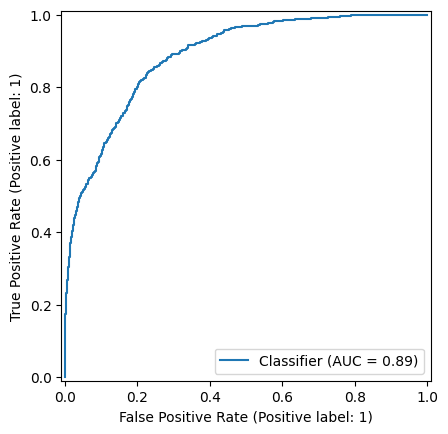

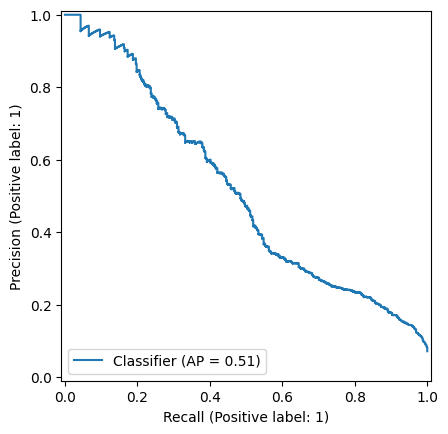

In [64]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

pipe_rf = Pipeline(steps=[("prep", ct), ("clf", rf)])
pipe_rf.fit(X_train, y_train)

proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

print("RandomForest")
print_metrics(y_test, proba_rf, pred_rf)
plot_curves(y_test, proba_rf, title="RandomForest")

# Limiar otimizado (Youden)
best_t_rf, _ = find_best_threshold(y_test, proba_rf, mode="youden")
pred_rf_opt = (proba_rf >= best_t_rf).astype(int)
print(f"\n→ Limiar Youden: {best_t_rf:.2f}")
print_metrics(y_test, proba_rf, pred_rf_opt)

# Permutation importance no PIPELINE (retorna importâncias por FEATURE ORIGINAL)
perm = permutation_importance(
    pipe_rf, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
imp_ser = (pd.Series(perm.importances_mean, index=feature_names_original)
           .sort_values(ascending=False))
imp_rf = imp_ser.head(20).reset_index()
imp_rf.columns = ["feature", "importance"]

fig = px.bar(imp_rf, x="importance", y="feature", orientation="h",
             title="Top 20 — Permutation Importance (features originais) | RandomForest",
             labels={"importance":"Impacto (↓ acurácia)", "feature":"Feature"},
             height=520, template="plotly_white")
fig.show()

imp_rf.head(10)

Modelo 3: HistGradientBoosting (rápido e forte)

HistGradientBoosting
ROC-AUC: 0.907 | PR-AUC (AP): 0.565

Classification report:
              precision    recall  f1-score   support

           0      0.949     0.994     0.971      6307
           1      0.800     0.305     0.442       485

    accuracy                          0.945      6792
   macro avg      0.874     0.650     0.706      6792
weighted avg      0.938     0.945     0.933      6792

Confusion matrix:
[[6270   37]
 [ 337  148]]



→ Limiar F2: 0.12
ROC-AUC: 0.907 | PR-AUC (AP): 0.565

Classification report:
              precision    recall  f1-score   support

           0      0.975     0.892     0.932      6307
           1      0.335     0.707     0.455       485

    accuracy                          0.879      6792
   macro avg      0.655     0.800     0.693      6792
weighted avg      0.930     0.879     0.898      6792

Confusion matrix:
[[5627  680]
 [ 142  343]]


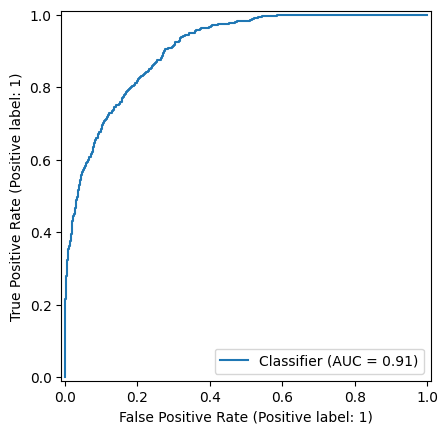

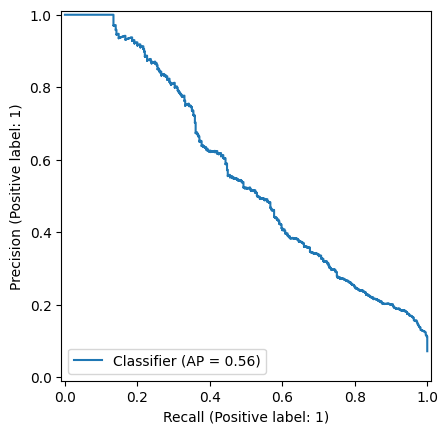

In [65]:
hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.08,
    max_bins=255,
    min_samples_leaf=20,
    l2_regularization=0.0,
    random_state=42
)

pipe_hgb = Pipeline(steps=[("prep", ct), ("clf", hgb)])
pipe_hgb.fit(X_train, y_train)

proba_hgb = pipe_hgb.predict_proba(X_test)[:, 1]
pred_hgb  = (proba_hgb >= 0.5).astype(int)

print("HistGradientBoosting")
print_metrics(y_test, proba_hgb, pred_hgb)
plot_curves(y_test, proba_hgb, title="HistGradientBoosting")

best_t_hgb, _ = find_best_threshold(y_test, proba_hgb, mode="f2")
pred_hgb_opt = (proba_hgb >= best_t_hgb).astype(int)
print(f"\n→ Limiar F2: {best_t_hgb:.2f}")
print_metrics(y_test, proba_hgb, pred_hgb_opt)

In [66]:
# Comparativo rápido

def summarize(name, y_true, proba, thr=0.5):
    return dict(
        modelo=name,
        roc_auc=roc_auc_score(y_true, proba),
        pr_auc=average_precision_score(y_true, proba),
        threshold=thr
    )

cmp = []
cmp.append(summarize("Logistic (0.5)", y_test, proba_log, 0.5))
cmp.append(summarize("RandomForest (0.5)", y_test, proba_rf, 0.5))
cmp.append(summarize("HGB (0.5)", y_test, proba_hgb, 0.5))
cmp.append(summarize(f"RandomForest (opt={best_t_rf:.2f})", y_test, proba_rf, best_t_rf))
cmp.append(summarize(f"HGB (opt={best_t_hgb:.2f})", y_test, proba_hgb, best_t_hgb))

df_cmp = pd.DataFrame(cmp).sort_values("pr_auc", ascending=False)
display(df_cmp)

fig = px.bar(df_cmp, x="modelo", y=["roc_auc","pr_auc"], barmode="group",
             title="Comparativo ROC-AUC x PR-AUC",
             labels={"value":"score","variable":"métrica","modelo":"modelo"},
             template="plotly_white", height=420)
fig.show()

,modelo,roc_auc,pr_auc,threshold
2,HGB (0.5),0.9069,0.5649,0.5000
4,HGB (opt=0.12),0.9069,0.5649,0.1200
1,RandomForest (0.5),0.8865,0.5139,0.5000
3,RandomForest (opt=0.28),0.8865,0.5139,0.2800
0,Logistic (0.5),0.8639,0.3697,0.5000
